In [1]:
%load_ext autoreload
%autoreload 2

# IMPORTS


In [2]:
# Project setup
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
# Standard library
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# Third-party libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from langdetect.detector_factory import DetectorFactory
from sklearn.model_selection import train_test_split

# Project modules
from src.config import PALETTE, HEATMAP_CMAP, RANDOM_STATE
from src.eda_utils import (
    column_summary,
    detect_language,
    eda_category,
    eda_numeric,
)

DetectorFactory.seed = RANDOM_STATE


In [4]:
# Exit notebooks/ and access the dataset in data/
data_path = project_root / "data" / "Airline_review.csv"
raw_df = pd.read_csv(data_path)

print('Train shape:', raw_df.shape)

Train shape: (23171, 20)


In [5]:
display(raw_df.sample(3, random_state=RANDOM_STATE))

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
17155,17155,Royal Jordanian Airlines,2,"""there was smoking on the plane""",27th June 2019,True,Tel Aviv to Amman. We had a short flight to ...,NaN,Couple Leisure,Business Class,Tel Aviv to Amman,May 2019,4.0,1.0,NaN,4.0,NaN,NaN,1.0,no
10119,10119,Frontier Airlines,1,"""Never flying with them again""",16th July 2023,False,Flight got delayed when I was flying to DR f...,NaN,Solo Leisure,Economy Class,Punta Cana to Miami,July 2023,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no
18821,18821,Southwest Airlines,1,"""no offered flight for 5 days""",28th December 2022,False,"Flying alone, my 14 year old daughter’s fligh...",NaN,Family Leisure,Economy Class,Salt Lake City to Dallas,December 2022,2.0,2.0,2.0,2.0,2.0,2.0,1.0,no


In [6]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  str    
 2   Overall_Rating          23171 non-null  str    
 3   Review_Title            23171 non-null  str    
 4   Review Date             23171 non-null  str    
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  str    
 7   Aircraft                7129 non-null   str    
 8   Type Of Traveller       19433 non-null  str    
 9   Seat Type               22075 non-null  str    
 10  Route                   19343 non-null  str    
 11  Date Flown              19417 non-null  str    
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null  float64
 

In [7]:
# number of duplicates
num_of_duplicates = raw_df.drop(columns='Unnamed: 0').duplicated().sum()
print(f'Number of duplicates: {num_of_duplicates}')

Number of duplicates: 120


In [8]:
# remove duplicates
raw_df = raw_df.drop_duplicates(subset=raw_df.columns.drop('Unnamed: 0'))

In [9]:
display(raw_df.describe().round(2))

,Unnamed: 0,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money
count,23051.00,19007.00,18902.00,14496.00,18369.00,10827.00,5918.00,22092.00
mean,11581.83,2.62,2.87,2.55,2.35,2.18,1.78,2.45
std,6704.20,1.46,1.60,1.53,1.60,1.49,1.32,1.59
min,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,5762.50,1.00,1.00,1.00,1.00,1.00,1.00,1.00
50%,11555.00,3.00,3.00,2.00,1.00,2.00,1.00,2.00
75%,17407.50,4.00,4.00,4.00,4.00,3.00,2.00,4.00
max,23170.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [10]:
print(f'Number of rows after removing duplicates: {raw_df.shape[0]}')

Number of rows after removing duplicates: 23051


In [11]:
# data types
print('Data types:')
display(raw_df.dtypes.value_counts().sort_values(ascending=False))

Data types:


str        11
float64     7
int64       1
bool        1
Name: count, dtype: int64

In [12]:
# missing values
null_df = (
    pd.DataFrame({
        'Null_count': raw_df.isnull().sum(),
        'Null_percentage': raw_df.isnull().mean() * 100
    })
    .sort_values(by='Null_percentage', ascending=False)
)

display(
    null_df.style
    .format({'Null_percentage': '{:.2f}%'})
    .background_gradient(cmap=HEATMAP_CMAP)
)


,Null_count,Null_percentage
Wifi & Connectivity,17133,74.33%
Aircraft,15924,69.08%
Inflight Entertainment,12224,53.03%
Food & Beverages,8555,37.11%
Ground Service,4682,20.31%
Cabin Staff Service,4149,18.00%
Seat Comfort,4044,17.54%
Route,3716,16.12%
Date Flown,3642,15.80%
Type Of Traveller,3627,15.73%


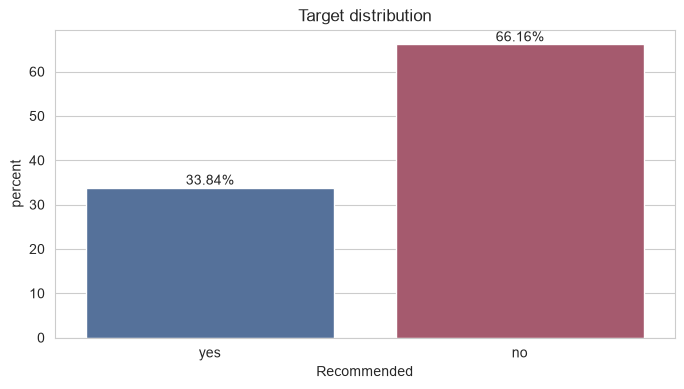

In [13]:
# class imbalance
plt.figure(figsize=(8, 4))

ax = sns.countplot(data=raw_df, x='Recommended', hue='Recommended', stat='percent', palette=PALETTE)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
    )
plt.title('Target distribution')
plt.show()

- The dataset contains of 23,171 airline reviews and 20 features, including the target variable.
- Most features are stored as the `object` type because they represent textual or categorical information. The remaining columns use integer, float, or boolean data types.
- Missing values are present in 12 features, ranging from 4.16% to 74.33%, and will be examined and handled during preprocessing.
- A total of **120 exact duplicate** records were identified and removed before splitting the data into the training, validation, and test sets.
- **After removing duplicates, the dataset contains 23,051 reviews and 20 features.**
- The target variable shows a moderate class imbalance, with approximately 66% of reviews labeled as "no" and 34% as "yes".
---

# 2\. EDA (Exploratory Data Analysis)

## 2.1 Data preparation

Data splitting into training, validation, and test sets to minimize the risk of making decisions based on information from the test set.

In [14]:
# split the raw data into training-validation and test sets (80/20)
train_val_df, test_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=raw_df['Recommended']
)

# split the training-validation data into training and validation sets (80/20)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_val_df['Recommended']
)

In [15]:
train_df = train_df.copy()
val_df = val_df.copy()

# create a binary target column ('yes' = 1, 'no' = 0)
train_df['Recommended_num'] = train_df['Recommended'].map({'yes': 1, 'no': 0})
val_df['Recommended_num'] = val_df['Recommended'].map({'yes': 1, 'no': 0})

# # create a list of feature columns, excluding the target variable and the redundant index column
# input_cols = [col for col in train_df.columns if col not in ['Recommended', 'Recommended_num', 'Unnamed: 0']]

target_col = 'Recommended_num'
target_cat_col = 'Recommended'

In [16]:
# split check
pd.DataFrame({
    'train': train_df['Recommended'].value_counts(normalize=True).round(4) * 100,
    'val': val_df['Recommended'].value_counts(normalize=True).round(4) * 100,
    'test': test_df['Recommended'].value_counts(normalize=True).round(4) * 100
})

,train,val,test
Recommended,,,
no,66.16,66.16,66.17
yes,33.84,33.84,33.83


## 2.2 Review information


### Review Date

In [17]:
# data overview
column_summary(train_df, 'Review Date')

==================== Column: Review Date ====================
Total number of values: 14752
Number of unique values: 4012
Number of missing values: 0 (0.00%)
Data type: str


In [18]:
# to_datetime
train_df['Review Date'] = train_df['Review Date'].str.replace(r'(\d{1,2})(st|nd|rd|th)', r'\1', regex=True)
train_df['Review Date'] = pd.to_datetime(train_df['Review Date'], format="%d %B %Y")

In [19]:
# datetime check
print(f'Min_value: {train_df['Review Date'].min()}')
print(f'Max_value: {train_df['Review Date'].max()}')

Min_value: 2002-02-14 00:00:00
Max_value: 2023-07-27 00:00:00


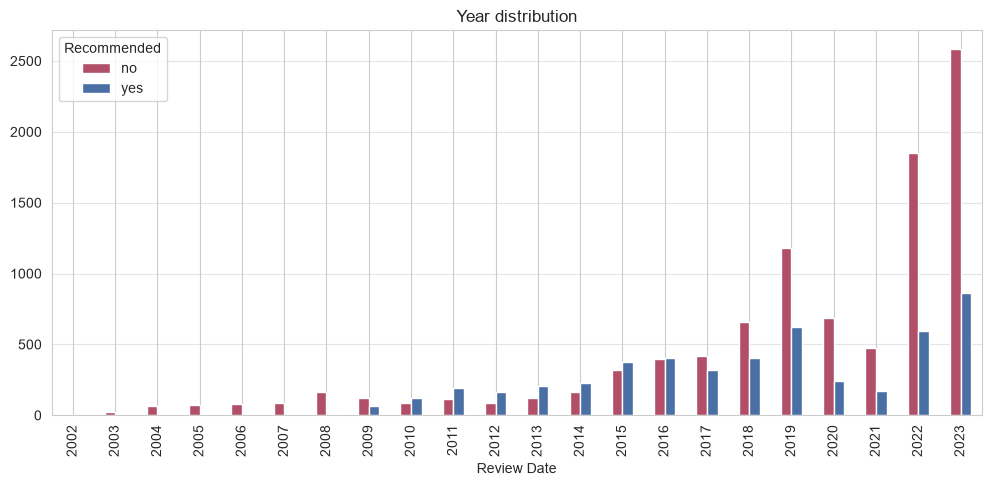

In [20]:
# year distribution visualization
year_target = (
    train_df
    .groupby(train_df['Review Date'].dt.year)['Recommended']
    .value_counts()
    .unstack()
)

year_target.plot(
    kind='bar',
    figsize=(12, 5),
    color=[PALETTE['no'], PALETTE['yes']]
)

plt.grid(axis='y', alpha=0.5)
plt.title('Year distribution')
plt.show()

The distribution of recommendations changes noticeably over time. However, this trend is likely influenced by multiple external factors (e.g., changes in the platform, user behavior, or the airline industry itself).

These factors are outside the scope of this project.

### Verified

==================== Column: Verified ====================
Total number of values: 14752
Number of unique values: 2
Number of missing values: 0 (0.00%)
Data type: bool
Skewness: -0.11


Verified,True,False
value_counts,7799.00,6953.00
value_percentage,52.87,47.13


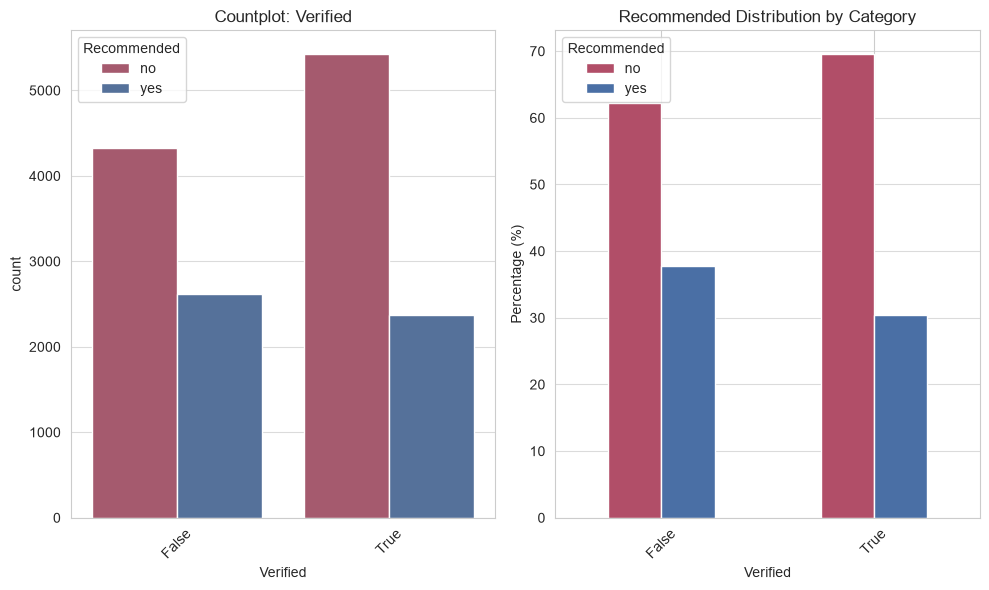

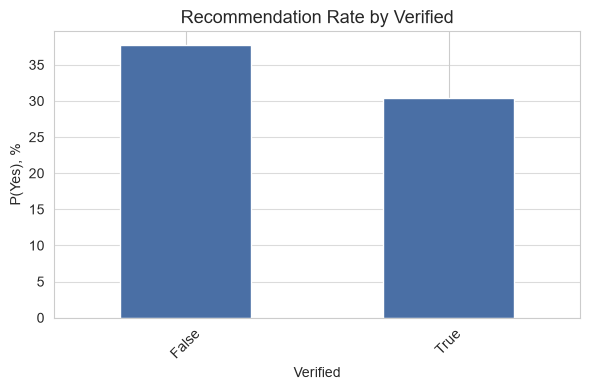

In [21]:
eda_category(train_df, 'Verified', target_cat_col)


In [22]:
print('Review Length by Verification Status')
display(train_df['Review'].str.len().groupby(train_df['Verified']).agg(['min', 'mean', 'max']))

Review Length by Verification Status


,min,mean,max
Verified,,,
False,91,670.283619,3642
True,105,765.894987,4043


In [23]:
print("Percentage Distribution of Overall Ratings by Verification Status")
display(pd.crosstab(train_df["Verified"], train_df["Overall_Rating"], normalize="index").round(4) * 100)

Percentage Distribution of Overall Ratings by Verification Status


Overall_Rating,1,2,3,4,5,6,7,8,9,n
Verified,,,,,,,,,,
False,41.16,9.52,5.97,4.16,4.85,3.49,5.84,9.08,8.63,7.31
True,58.11,10.64,5.73,3.17,2.47,2.55,4.39,6.15,6.78,0.00


- Verified is relatively balanced (53.3% verified vs. 46.7% non-verified) and contains no missing values.
- Verified reviewers tend to write slightly longer reviews.
- Verified users appear to assign the lowest overall rating more frequently than non-verified users.

However, the relationship between Verified and the target variable (Recommended) is weak, suggesting that this feature is unlikely to be a strong predictor.

The Verified feature will excluded because its value may change over time as reviews are verified after publication. Manual inspection also revealed inconsistencies between the dataset and the current website, making this feature unreliable for modeling.

### Review_Title

In [24]:
# duplicate rows
duplicate_rows = train_df['Review_Title'].duplicated().sum()
duplicate_percentage = duplicate_rows / train_df['Review_Title'].shape[0] * 100

print(f'Dulicate rows: {duplicate_rows} ({duplicate_percentage:.2f}%)')

Dulicate rows: 3483 (23.61%)


In [25]:
display(train_df['Review_Title'].value_counts().iloc[115:122])

Review_Title
Air Zimbabwe customer review         10
"worst airline I have ever flown"     9
Air Busan customer review             9
Shandong Airlines customer review     9
Surinam Airways customer review       9
Aerosur customer review               9
Air Madagascar customer review        9
Name: count, dtype: int64

In [26]:
print(
    f'Rows contain "customer review": {train_df['Review_Title'].str.contains("customer review", case=False, na=False).mean() * 100: .2f}%')

Rows contain "customer review":  17.88%


- `Review_Title` contains 3,483 duplicated values (23.61% of the training set).
- About 17.88% of all titles contain the phrase *customer review* (without quotation marks), following the pattern "< Airline Name > customer review". This suggests that some review titles were automatically generated using a template rather than provided by users.
- The remaining duplicated titles mostly consist of short, generic phrases such as *"worst airline I have ever flown"*, *"Very poor service"*, or *"the worst experience"*, which are plausible user-written headings.

In [27]:
# 'Title_word_count' column
train_df['Title_word_count'] = train_df['Review_Title'].str.split().str.len()

# 'Title_char_count' column
train_df['Title_char_count'] = train_df['Review_Title'].str.len()

==================== Column: Title_word_count ====================
Total number of values: 14752
Number of unique values: 16
Number of missing values: 0 (0.00%)
Data type: int64
Skewness: 1.15
Outliers: 1960 (13.29%)
Median for "no": 5.0
Median for "yes": 4.0
count    14752.00
mean         4.66
std          1.51
min          1.00
25%          4.00
50%          4.00
75%          5.00
max         16.00
Name: Title_word_count, dtype: float64


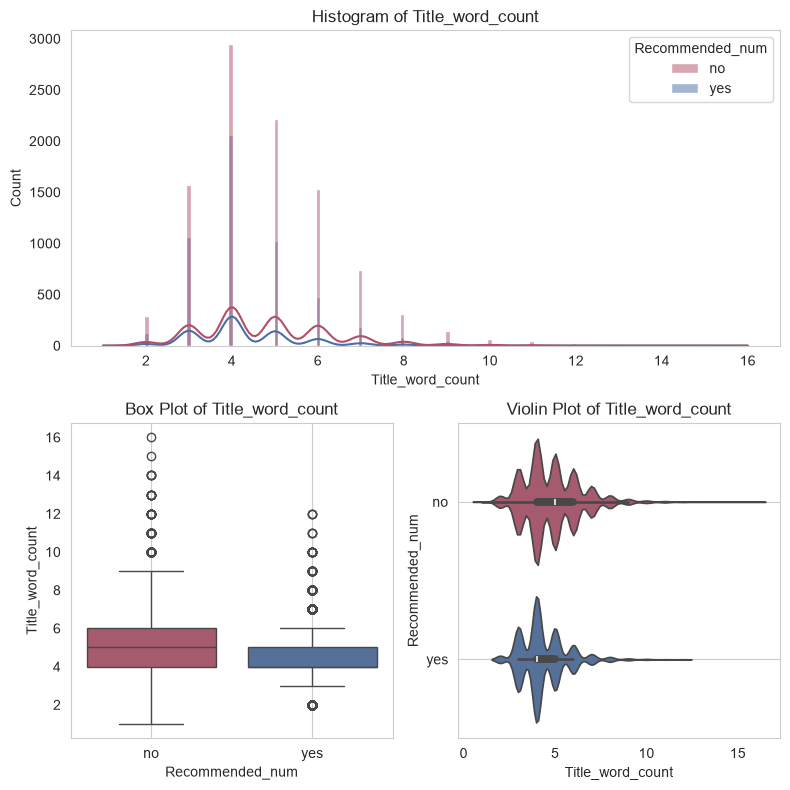

In [28]:
eda_numeric(train_df, 'Title_word_count', target_col)

- Review titles are generally short, with a median of 4 words and an average of 4.66 words.
- The distribution is slightly right-skewed (skewness = 1.15), meaning that most titles are short, while long titles appear less frequently.
- Reviews labeled as `not recommended` have slightly longer titles (median = 5 words) than `recommended` reviews (median = 4 words).
- The histogram and violin plot show a substantial overlap between the distributions of the two classes.
Therefore, title length alone is unlikely to be a useful predictor of the target variable.

==================== Column: Title_char_count ====================
Total number of values: 14752
Number of unique values: 69
Number of missing values: 0 (0.00%)
Data type: int64
Skewness: 1.16
Outliers: 421 (2.85%)
Median for "no": 30.0
Median for "yes": 28.0
count    14752.00
mean        29.83
std          7.08
min          2.00
25%         25.00
50%         29.00
75%         33.00
max         83.00
Name: Title_char_count, dtype: float64


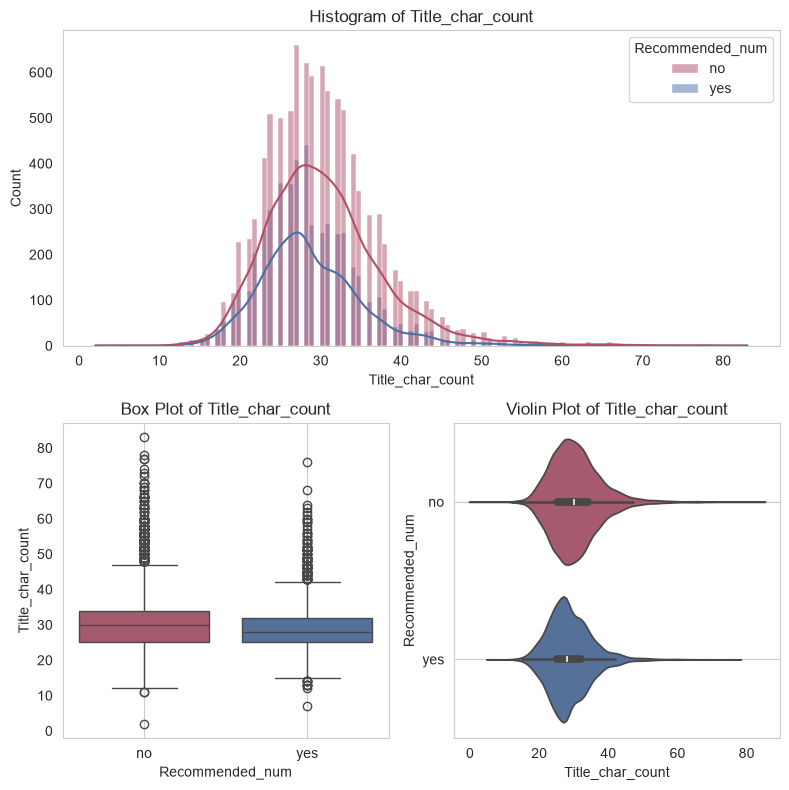

In [29]:
eda_numeric(train_df, 'Title_char_count', target_col)

Both features `Title_word_count` and `Title_char_count` showed practically identical behavior with respect to the target:
- the medians differ minimally;
- the distributions overlap almost completely;
- neither demonstrates good class separation.

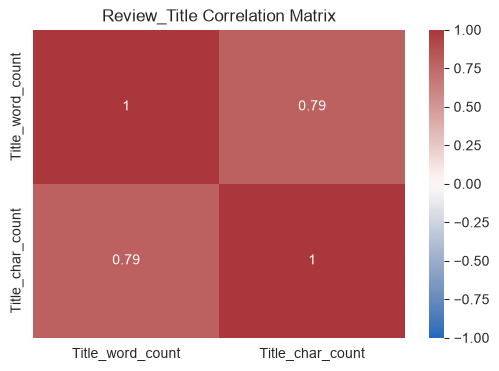

In [30]:
# correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    train_df[['Title_word_count', 'Title_char_count']].corr(),
    annot=True,
    cmap=HEATMAP_CMAP,
    vmin=-1,
    vmax=1
)

plt.title('Review_Title Correlation Matrix')
plt.show()

`Title_word_count` and `Title_char_count` are moderately to strongly correlated (Pearson's r = 0.79). Although they capture similar aspects of title length, the correlation is not high enough to consider them redundant. Their usefulness will be reassessed during feature selection.

### Review

In [31]:
# duplicate rows
duplicate_review_rows = train_df['Review'].duplicated(keep=False).sum()

print(f'Dulicate Review rows: {duplicate_review_rows}')

Dulicate Review rows: 0


After removing exact duplicate records, all review texts are unique.

In [32]:
# 'Review_word_count' column
train_df['Review_word_count'] = train_df['Review'].str.split().str.len()

# 'Review_char_count' column
train_df['Review_char_count'] = train_df['Review'].str.len()

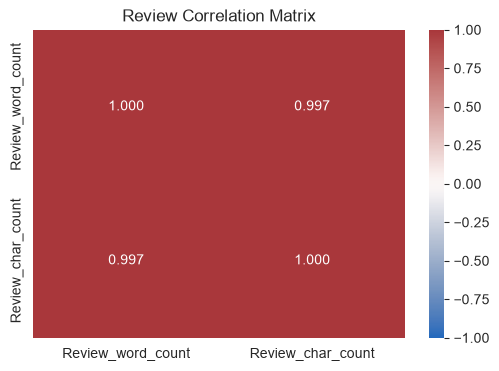

In [33]:
# correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    train_df[['Review_word_count', 'Review_char_count']].corr(),
    annot=True,
    fmt='.3f',
    cmap=HEATMAP_CMAP,
    vmin=-1,
    vmax=1
)

plt.title('Review Correlation Matrix')
plt.show()

`Review_word_count` and `Review_char_count` are very strongly correlated (Pearson's r = 0.997). Both features measure the length of the review in different ways, so they provide almost the same information. Their usefulness will be reassessed during feature selection.

==================== Column: Review_word_count ====================
Total number of values: 14752
Number of unique values: 588
Number of missing values: 0 (0.00%)
Data type: int64
Skewness: 2.03
Outliers: 803 (5.44%)
Median for "no": 114.0
Median for "yes": 82.0
count    14752.00
mean       130.45
std         98.28
min         14.00
25%         64.00
50%        102.00
75%        164.00
max        734.00
Name: Review_word_count, dtype: float64


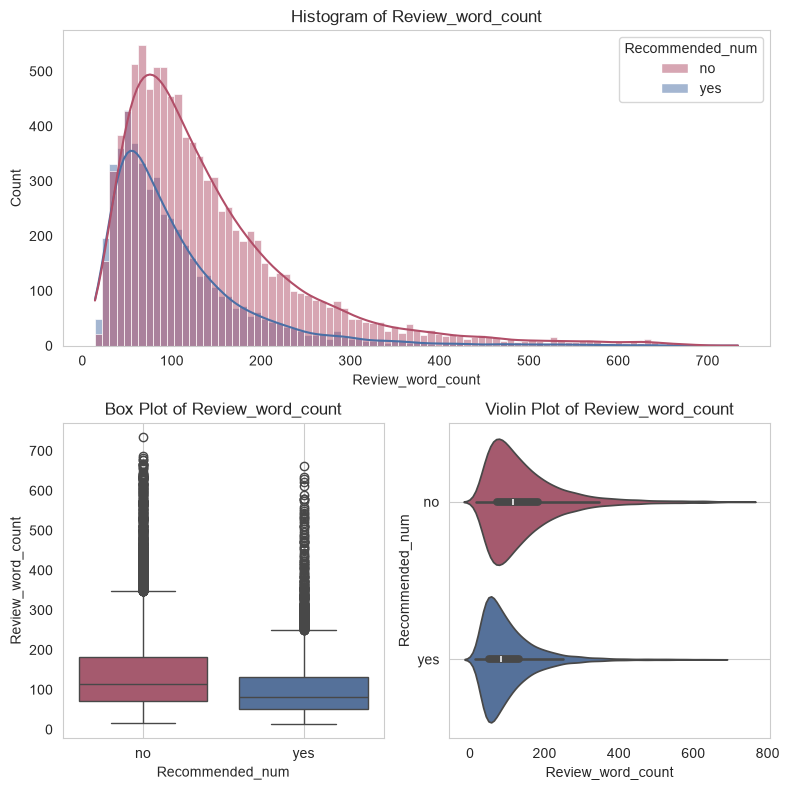

In [34]:
eda_numeric(train_df, 'Review_word_count', target_col)

Negative reviews tend to be longer than positive ones. Although the distributions overlap, review length shows some relationship with the target and may be a useful auxiliary feature.

In [35]:
# identification of the review language
train_df['language'] = train_df['Review'].apply(detect_language)

In [36]:
print('Review language:')
display(train_df['language'].value_counts(normalize=True).round(4) * 100)

Review language:


language
en    99.79
fr     0.12
es     0.02
id     0.01
it     0.01
nl     0.01
de     0.01
ru     0.01
no     0.01
sv     0.01
Name: proportion, dtype: float64

In [37]:
# manual inspection of language detection results
with pd.option_context('display.max_colwidth', None):
    print('Reviews detected as French')
    display(train_df.loc[train_df['language'] == 'fr', ['Review_Title', 'Review']].head(3))
    print('=' * 200)
    print('Reviews detected as German')
    display(train_df.loc[train_df['language'] == 'de', ['Review_Title', 'Review']])
    print('=' * 200)
    print('Reviews detected as Spain')
    display(train_df.loc[train_df['language'] == 'es', ['Review_Title', 'Review']])



Reviews detected as French


,Review_Title,Review
13594,"""received vouchers which do not work""","It has been several times that I have claimed reimbursement for my plane tickets whose flight has been canceled. The first time on June 4, 2020. Latam advised me that the refund would take 15 days, I'm still waiting! In the meantime I have received vouchers, which do not work: I wanted to pay for my last flights with and they were refused. This company is a company of thieves: they promise and do not not keep their promises. They don't even know how to use a translator and force you to send your request in a language that is not yours. Again the answer to my complaint is that I have vouchers to use (which don't not work!) and if I keep asking for the refund, it will take a long time. Cela fait plusieurs fois que je réclame le remboursement de mes billets d'avion dont le vol a été annulé. La première fois le 4 juin 2020. Latam m'a avisé que le remboursement prendrait 15 jours, J'attends toujours! Entre temps j'ai reçu des voucher, qui ne fonctionnent pas: j'ai voulu payer mes derniers vols avec et ils ont été refusés..... Ils promettent et ne tiennent pas leurs promesses. Ils ne savent même pas utiliser un traducteur et vous obligent à envoyer votre demande dans une langue qui n'est pas la vôtre. Une nouvelle fois la réponse à ma réclamation est que j'ai des vouchers à utiliser (qui ne fonctionnent pas!) et si je persiste à demander le remboursement, ça prendra beaucoup de temps."
22453,"""Friendly cabin crew""","Boarding done in advance. Perfect trip and early arrival. Friendly cabin crew. Captain who communicates throughout the flight. Excellent service, I recommend! Embarquement réalisé en avance. Voyage parfait et arrivée en avance. Personnel de cabine bienveillant. Commandant de bord qui communique tout au long du vol. Excellente prestation, je recommande !"
429,"""Low-end at a bargain price""","Buenos Aires to Rio Grande. When you enter a plane of aerolineas, you immediately fall on the reward of Trip, it gives confidence. Mistake, our 2 flights were incredible, both late (25 minutes for the first and 1:30 for the second), no information, we only warn you when the boarding time arrives, quietly. Following the bad reviews on the forums, and the endless malfunction of the website, we decided to go to the Ushuaia agency to get info on our flight back which was currently nonexistent. ou arrive at check in and there are twenty people at the opening, count 10 to 15 minutes per person minimum. The flight: late, in a dirty plane, the hostesses jostle, splashes and the breakfast is served by running because it seems that it is already very late to do so and for good reason, we land almost at the same time. Add to that the difficulties to pay a ticket on the site, the total lack of communication (no response on any media available), that's a lot for the same company. In short, we are far from paradise. Low-end company at a bargain price! FR: Quand vous entrez dans un avion d'aerolineas, vous tombez de suite sur la récompense de Trip, ça donne confiance. Erreur, nos 2 vols ont été incroyables, les deux en retards (25 minutes pour le premiers et 1h30 pour le second), aucune information, on ne vous prévient qu'on moment où l'heure d'embarquement arrive, tranquillement. L'enregistrement est long, mais long, 40 minutes pour passer une trentaine de personnes. Suite aux mauvaises critiques sur les forums, et au dysfonctionnement sans fin du site internet, nous avons décidé de nous rendre dans l'agence d'Ushuaia pour avoir des infos sur notre vol de retour qui était pour l'instant inexistant... Bin alors là faut oublier, vous arrivez à l'agence et il y a une vingtaine de personnes à l'ouverture, comptez 10 à 15 minutes par personne minimum... Le vol : en retard, dans un avion sale, les hôtesses sont de vraies brutes, on vous bouscule, vous éclabousse et le petit-dej est servi en courant car il semblerait qu'il soit déjà très tard pour le faire et pour cause, on atterrit 

Reviews detected as German


,Review_Title,Review
9111,"""flight was either canceled or postponed""","In the last 2 years, almost every time I booked a flight with Eurowings, the flight was either canceled or postponed (and new times were completely useless). It is not worth booking a flight with this airline. Refunds were not always made! You are very unreliable. In den letzten 2 Jahren, fast immer wenn ich einen Flug mit Eurowings gebucht habe, der Flug wurde entweder abgesagt oder verschoben (und neue Zeiten waren komplett sinnlos). Es loht sich gar nicht einen Flug mit dieser Fluggeselschaft zu buchen. Gelderstattung wurde nicht immer gemacht! Sie sind sehr unzuverlässig."
567,"""very rude how you are treated""","Aeromexico didn't tell me about the visa when I checked in, then I lost the flight because Oficina sent me back and forth. I had to pay an exaggerated new ticket of 2500 euros. A return flight from Mexico to Germany. My luggage is gone too, I'll probably never see it again. Partly very rude how you are treated, no advice and no help. Somehow even foreigners Hostile. I speak spanish but not perfect. I will never fly with Aeromexico again because they ripped it off badly. A short phone call was enough in their own ranks to help me, Aeromexico hat mich beim Einchecken nicht auf dass Visa hingewiesen,dann habe ich den Flug verloren ,weil dass Oficina mich hin und her geschickt hat. Ein übertriebenes neues Ticket von 2500 Euro musste ich bezahlen. Ein Rückflug von Mexiko nach Deutschland. Mein Gepäck ist auch verschwunden,werde es wohl nie wieder sehen. Zum Teil sehr unverschämt wie man behandelt wird,keine Beratung und keine Hilfe. Irgendwie sogar Ausländer Feindlich. Ich rede Spanisch,aber nicht perfekt. Ich werde nie mehr mit Aeromexico fliegen,denn sie haben kräftig übers Ohr gehauen. Ein kurzes Telefonat hatte ausgereicht in ihren eigenen Reihen um mir zu helfen"


Reviews detected as Spain


,Review_Title,Review
22677,"""está sola y ya sin medicamento""","Cali to Panama. Que un representante sea un total patan y grosero, aunque haya agentes decentes, deja caer mal a todo el equipo. Mi mamá, una señora de la tercera edad e hipertensa, fue humillada y maltratada por un agente en Cali. Hasta uno de los de migración, le pidieron respeto a la Sra. Desde el inicio no respondió ni los buenos días, le pidió un dinero en efectivo y dice que le faltan $100 para poder viajar y no la dejo ni hablar y la corrió de inmediato, dijo: siguiente retírese no viaja así y punto? Increíble, ahora mi mamá tiene la tensión alta con los nervios acelerados, no la dejaron viajar, no sabe que hacer, está sola y ya sin medicamento."
4989,"""don't give a drop of water""","Avianca I traveled to Colombia from Canada, a 6-hour flight one way on an 320 and back on an A319. I paid $1,150 dollars and they don't give a drop of water, the seats are super uncomfortable. Avianca viajé a Colombia desde Canadá, un vuelo de 6 horas a la ida en un A320 y de regreso en A319. Pagué $1,150 dollares y no dan ni una gota de agua, los puestos super incómodos. Es el colmo con esta compañía como abusa de sus usuarios. Invito a no volar con ellos"
22097,"""service is poor to miserable""","Flight Bogotá Lima. Reclining chairs, but barely room for my legs in the chair (I measure 1.75). I had to pay extra to sit next to my wife. All the time in fear that the bags we carry would be extra charged. Cuzco Lima Not even a USB port to charge cell phone or tablet. Everything, including water is charged. Plastic chairs that do not recline, just better than those on an urban bus. My wife changed position with a woman since she had been separated from her 5 year old son. Lima Bogotá We had to pay 40 us for printing 2 passports. The same fear that the suitcase will be charged extra for passing us a couple of centimeters. Plastic chairs do not recline, for a 3-hour flight. I did not sit next to my wife, for not paying extra. If they could, they would charge the toilet paper per square. Really awkward. I understand that it is low cost, but the service is poor to miserable. No screen, no usb port, no water, no space, no comfort. Everything has to pay extra. In the end, it ends up leaving at the same price or even more expensive than better airlines like Lan or Avianca. Vuelo Bogotá Lima. Sillas que reclinan, pero apenas espacio para mis piernas en la silla (mido 1.75). Tuve que pagar extra para sentarme al lado de mi esposa. Todo el tiempo con miedo de que las maletas que llevavamos fueran a ser cobradas extra. Cuzco Lima. Ni siquiera un puerto usb para cargar celular o tableta. Todo, incluyendo agua es cobrado. Sillas plásticas que no reclinan, apenas mejores que las que hay en un bus urbano. Mi esposa cambio puesto con una mujer ya que habia quedado separada de su hijo de 5 años. Lima Bogotá. Tuvimos que pagar 40 us por imprimir 2 pasabordos. El mismo miedo de que la maleta la cobraran extra por pasarnos un par de centímetros. Sillas plásticas.no reclinan, para un vuelo de 3 h. No me senté al lado de mi esposa, por no pagar extra. Si pudieran, cobrarían el papel higieníco por cuadrado. Realmente incómodo. Entiendo que es bajo costo, pero el servicio se pasa a miserable. No pantalla, no puerto usb, no agua, no espacio, no comodidad. Todo toca pagar extra. Al final, termina saliendo al mismo precio o incluso más caro que aerolíneas mejores como lan o Avianca."


Language detection showed that more than 99.8% of reviews were identified as English. The remaining reviews contained both English and another language rather than being entirely non-English. Since all of them included English text, no reviews were removed based on language.

---
The `Review` text is expected to be the most informative feature for predicting recommendations. After preprocessing, the review text will be transformed into numerical representations using text vectorization techniques.

Basic statistics may provide additional information, but their actual contribution will be assessed during feature selection.

## 2.3 Flight information

### Airline Name

In [38]:
# statistics
column_summary(train_df, 'Airline Name')

==================== Column: Airline Name ====================
Total number of values: 14752
Number of unique values: 478
Number of missing values: 0 (0.00%)
Data type: str


In [39]:
# single review
single_review_num = train_df[train_df.groupby('Airline Name')['Airline Name'].transform('count') == 1].shape[0]
print('Number of airlines with a single review:', single_review_num)

Number of airlines with a single review: 50


In [40]:
# the most frequent airlines
print('The most frequent airlines:')
display(train_df['Airline Name'].value_counts().head(10))

The most frequent airlines:


Airline Name
Thai Airways                 76
Nok Air                      74
SATA Air Azores              74
flydubai                     73
Air Mauritius                73
LOT Polish Airlines          72
Jetstar Pacific              72
British Airways              71
LAN Airlines                 71
Aeroflot Russian Airlines    71
Name: count, dtype: int64

- The dataset contains 478 unique airlines, indicating a high-cardinality feature.
- 50 airlines (10.5%) are represented by a single review.
- No single airline dominates the dataset, with the most frequent airline appearing only 76 times.
- The reviews are collected from many different airlines rather than being concentrated around a few carriers.

Due to its high cardinality and sparse distribution, the `Airline Name` feature is unlikely to provide reliable predictive value and will therefore be excluded from further modeling.


### Aircraft

In [41]:
# statistics
column_summary(train_df, 'Aircraft')

==================== Column: Aircraft ====================
Total number of values: 14752
Number of unique values: 745
Number of missing values: 10163 (68.89%)
Data type: str


- The `Aircraft` feature contains 68.89% missing values, and the missing entries are spread across different years;
- 745 unique values ​​indicate high cardinality.

Therefore, `Aircraft` is a weak candidate for inclusion in the model.

### Route


In [42]:
# statistics
column_summary(train_df, 'Route')

==================== Column: Route ====================
Total number of values: 14752
Number of unique values: 9309
Number of missing values: 2449 (16.60%)
Data type: str


In [43]:
single_routes_num = train_df[train_df.groupby('Route')['Route'].transform('count') == 1].shape[0]
print('Number of single routes:', single_routes_num)

Number of single routes: 7831


- *Route* contains 9,309 unique values.
- 7,831 routes (84.12%) appear only once.

Due to its extremely high cardinality and sparse representation, `Route` is a strong candidate for removal.

### Date Flown

In [44]:
# data overview
column_summary(train_df, 'Date Flown')

==================== Column: Date Flown ====================
Total number of values: 14752
Number of unique values: 107
Number of missing values: 2401 (16.28%)
Data type: str


In [45]:
display(train_df['Date Flown'].head(3))

11763       July 2022
19752      April 2019
4064     January 2023
Name: Date Flown, dtype: str

In [46]:
# to_datetime
train_df['Date Flown'] = pd.to_datetime(
    train_df['Date Flown'],
    format='%B %Y'
).dt.to_period('M')
display(train_df['Date Flown'].head(2))

11763    2022-07
19752    2019-04
Name: Date Flown, dtype: period[M]

In [47]:
# datetime check
print(f'Min_value: {train_df["Date Flown"].min()}')
print(f'Max_value: {train_df["Date Flown"].max()}')

Min_value: 2014-08
Max_value: 2023-07


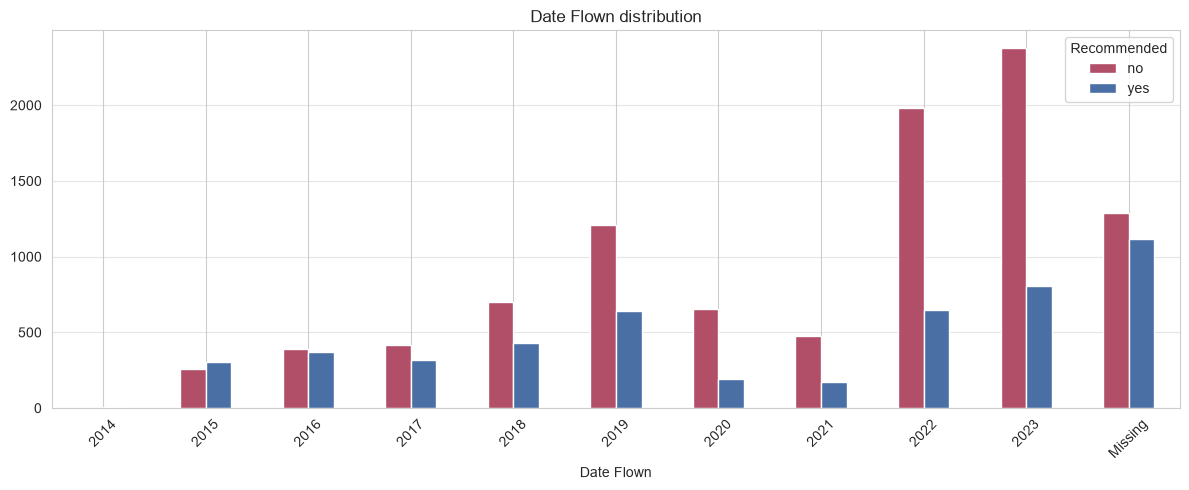

In [48]:
year = (
    train_df['Date Flown']
    .dt.year
    .fillna(-1)
    .astype(int)
    .astype(str)
    .replace('-1', 'Missing')  # Шукаємо саме рядок '-1'
)

flown_target = (
    train_df
    .groupby(year)['Recommended']
    .value_counts()
    .unstack()
)

plt.figure(figsize=(12, 5))
flown_target.plot(
    kind='bar',
    ax=plt.gca(),
    color=[PALETTE['no'], PALETTE['yes']]
)

plt.grid(axis='y', alpha=0.5)
plt.title('Date Flown distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- The dataset primarily covers flights from 2015 to 2023.
- 16.28% of the data is missing.
- The number of reviews has been increasing in recent years.

This feature will be excluded from the model, as the observed trends are likely driven by external factors rather than review characteristics.

---
Most Flight Information features appear to have limited potential for solving the forecasting task. Their contribution will be assessed during the feature selection stage prior to model training.

## 2.4 Traveller information

### Type Of Traveller

==================== Column: Type Of Traveller ====================
Total number of values: 14752
Number of unique values: 4
Number of missing values: 2388 (16.19%)
Data type: str


Type Of Traveller,Missing values,Solo Leisure,Couple Leisure,Family Leisure,Business
value_counts,2388.00,4476.00,3400.00,2761.00,1727.00
value_percentage,16.19,30.34,23.05,18.72,11.71


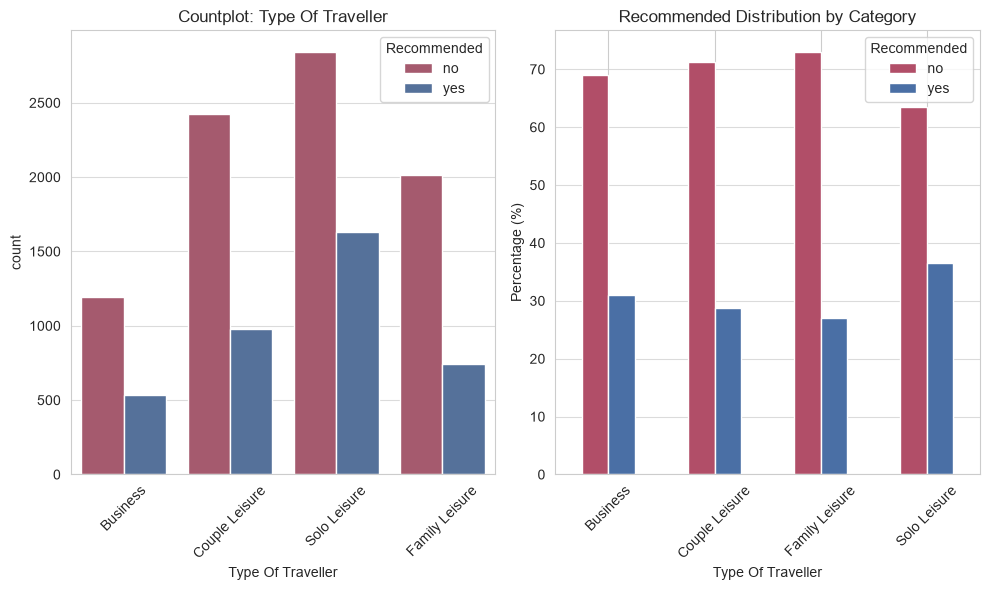

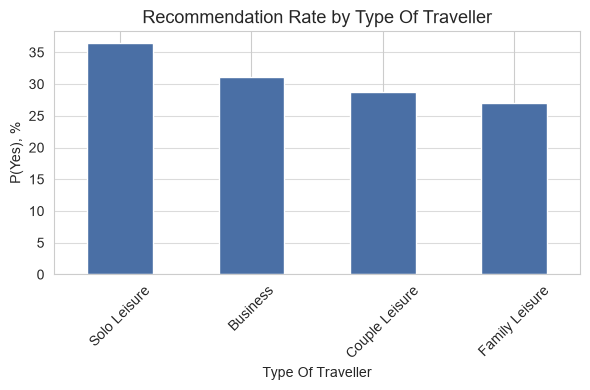

In [49]:
eda_category(train_df, 'Type Of Traveller', target_cat_col)

`Type of Traveller` has only 4 categories and shows noticeable differences in recommendation rates between traveller groups.
 Despite 16.19% missing values, it appears to be a useful feature for the prediction task.

### Seat Type

==================== Column: Seat Type ====================
Total number of values: 14752
Number of unique values: 4
Number of missing values: 652 (4.42%)
Data type: str


Seat Type,Missing values,Economy Class,Business Class,Premium Economy,First Class
value_counts,652.00,12196.00,1351.00,429.00,124.00
value_percentage,4.42,82.67,9.16,2.91,0.84


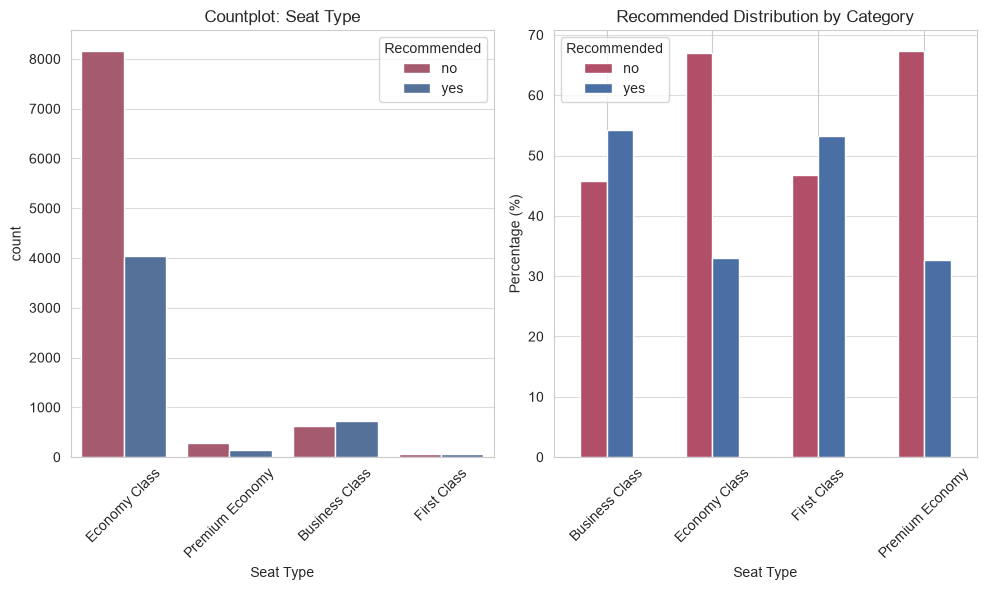

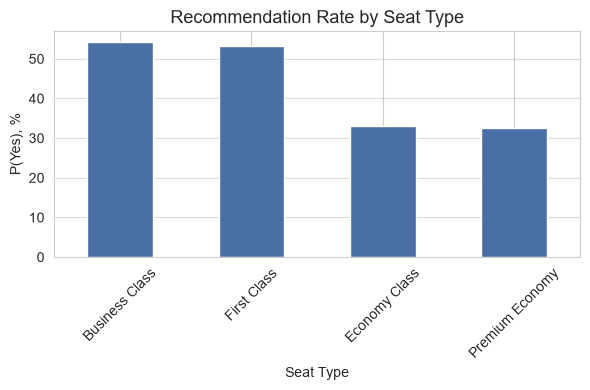

In [50]:
eda_category(train_df, 'Seat Type', target_cat_col)

The `Seat Type` feature also has low cardinality (four categories) and only 4.42% missing values. Recommendation rates differ noticeably between seat classes, indicating that this feature may be a useful predictor.

`Seat Type` has a natural ordering (Economy → Premium Economy → Business → First), so this feature can be encoded using ordinal encoding.

## 2.5 Service ratings

### Service ratings overview

In [51]:
# 'Overall_Rating' to numeric
train_df['Overall_Rating'] = pd.to_numeric(
    train_df['Overall_Rating'],
    errors='coerce'
)

service_ratings = ['Overall_Rating', 'Seat Comfort',
                   'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
                   'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money']

display(train_df[service_ratings].describe().round(2))

,Overall_Rating,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money
count,14244.00,12149.00,12084.00,9278.00,11711.00,6907.00,3775.00,14122.00
mean,3.14,2.62,2.88,2.56,2.36,2.18,1.78,2.46
std,2.88,1.47,1.61,1.53,1.59,1.49,1.32,1.59
min,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
50%,1.00,3.00,3.00,2.00,1.00,2.00,1.00,2.00
75%,5.00,4.00,4.00,4.00,4.00,3.00,2.00,4.00
max,9.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


- Most service rating features use a 0–5 scale.
- `Ground Service` ranges from 1 to 5.
- `Overall_Rating` is measured on a different scale, ranging from 1 to 9.

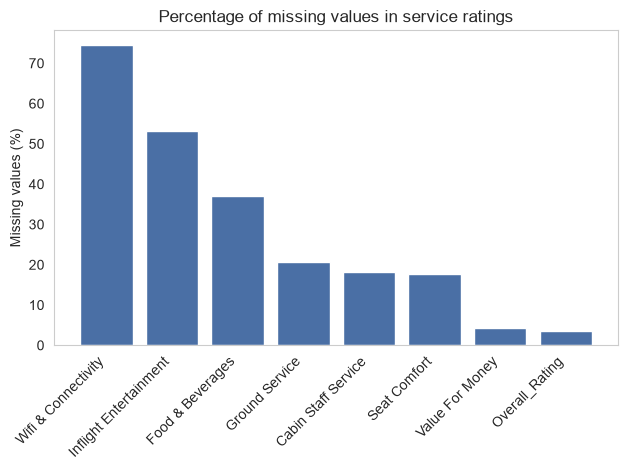

In [57]:
# missing values in service ratings
missing_service_values = (
    train_df[service_ratings]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.bar(missing_service_values.index, missing_service_values, color=PALETTE['yes'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing values (%)')
plt.title('Percentage of missing values in service ratings')
plt.tight_layout()
plt.grid()
plt.show()

The proportion of missing values varies considerably across the features. The highest number of missing values is observed for services that may not be available on all flights (Wi-Fi, inflight entertainment, and food & beverages). Therefore, these missing values are likely related to flight characteristics rather than data quality issues and should be taken into account during preprocessing.

### Overall_Rating

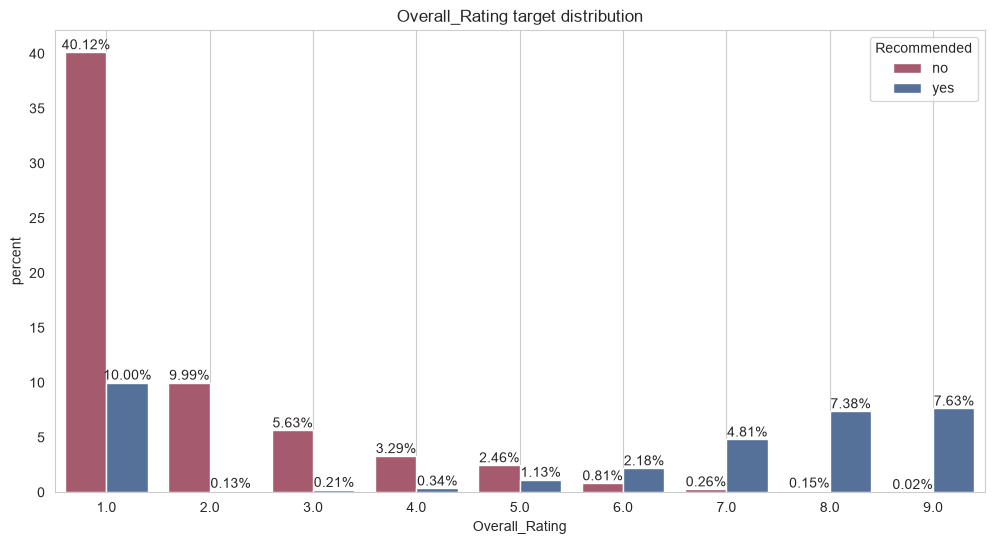

In [53]:
# Overall_Rating distribution
plt.figure(figsize=(12, 6))

ax = sns.countplot(data=train_df, x='Overall_Rating', hue='Recommended', stat='percent', palette=PALETTE)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
    )
plt.title('Overall_Rating target distribution')
plt.grid()
plt.show()


The proportion of positive recommendations for `Overall_Rating`=1 is **abnormally high**.

In [54]:
train_df[(train_df['Overall_Rating'] == 1) & (train_df['Recommended'] == 'yes')].head(3)

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,...,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended,Recommended_num,Title_word_count,Title_char_count,Review_word_count,Review_char_count,language
17051,17051,Royal Brunei Airlines,1.0,Royal Brunei Airlines customer review,2015-07-01,False,What can I say. Third trip to Dubai and have u...,NaN,Family Leisure,Economy Class,...,5.0,NaN,5.0,yes,1,5,37,91,525,en
17054,17054,Royal Brunei Airlines,1.0,Royal Brunei Airlines customer review,2015-05-16,False,Flew from MEL-CGK via BWN. They changed our fl...,NaN,NaN,Economy Class,...,5.0,NaN,5.0,yes,1,5,37,254,1358,en
2431,2431,Air Namibia,1.0,"""an incredible service""",2016-01-06,False,"During this Air Namibia flight, I received exc...",NaN,Solo Leisure,Economy Class,...,NaN,NaN,5.0,yes,1,3,23,231,1262,en


During the analysis of the `Overall_Rating` feature, an unusually high proportion of positive recommendations was observed among reviews with an overall rating of 1. In addition, many of these reviews contained high scores for other service ratings and clearly positive review text, which was inconsistent with such a low `Overall_Rating`.

To investigate this anomaly, several reviews were manually compared with their original versions on the [AirlineQuality website](https://https://www.airlinequality.com), the source of the dataset. In all examined cases, reviews with an `Overall Rating` of 10/10 on the website were stored as 1 in the dataset.



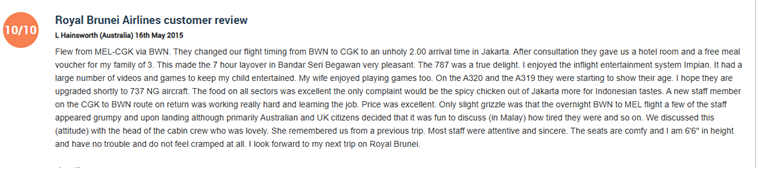

In [55]:
# same review from dataset
train_df.loc[17054, ['Overall_Rating', 'Review_Title', 'Review Date', 'Airline Name', 'Review']]

Overall_Rating                                                  1.0
Review_Title                  Royal Brunei Airlines customer review
Review Date                                     2015-05-16 00:00:00
Airline Name                                  Royal Brunei Airlines
Review            Flew from MEL-CGK via BWN. They changed our fl...
Name: 17054, dtype: object

The original scraping code ([github.com](https://https://github.com/Juhibhojani/Airline-Reviews-/blob/main/airline_review.py)) was then reviewed, revealing the cause of this issue. The overall rating was extracted using rating.text.strip()[:1], which keeps only the first character of the rating. As a result, all ratings of 10 were incorrectly stored as 1.


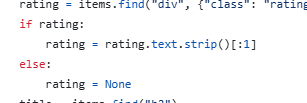

Since it is impossible to reliably distinguish genuine 1/10 ratings from those incorrectly converted from 10/10, the Overall_Rating feature was excluded from further analysis and model training.

### Service ratings correlation

<Axes: >

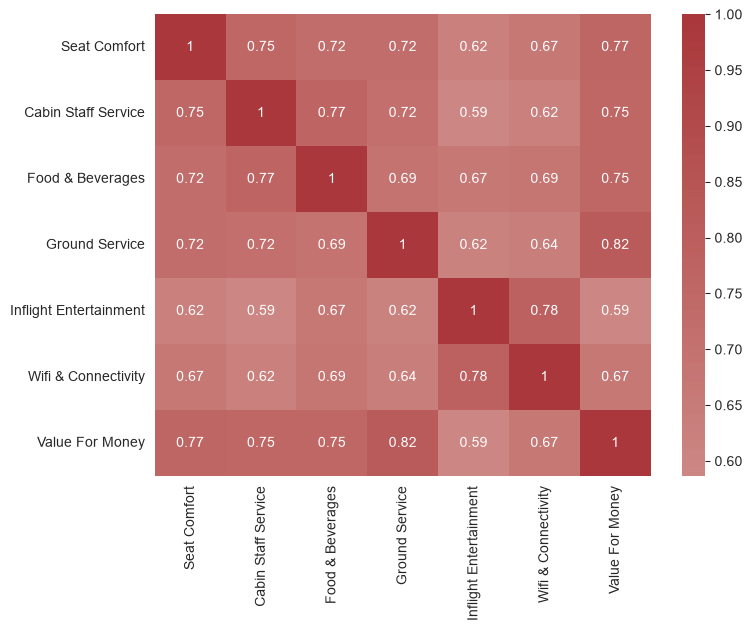

In [56]:
# service ratings without 'Overall_Rating'
service_columns = ['Seat Comfort',
                   'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
                   'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money']

service_corr = train_df[service_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(service_corr, annot=True, cmap=HEATMAP_CMAP, center=0)


Service ratings show moderate to strong positive correlations with each other (≈0.59–0.82) , indicating that passengers tend to rate different aspects of the flight consistently. However, these ratings are unlikely to be fully interchangeable and will therefore be retained for model training.

# 3\. EDA Summary
EDA showed that both the review text and several structured features may be useful for predicting whether a passenger recommends an airline. The review text is expected to be the main source of information and will be processed separately using text embeddings. Service ratings, traveller type, and seat type will be included in the models, while `Review Date`, `Verified`, `Route`, `Airline Name`, `Aircraft`, `Date Flown`, and `Overall_Rating` will be excluded due to high cardinality, a large number of missing values, and a confirmed data quality issue, respectively. The next step is data preprocessing and model training.